# Demo 4: AUTO-07P Benchmark Demo `ab` (Run 3) — Two-Parameter Bifurcation Analysis (Codimension-2)

In this tutorial, we reproduce **Run 3 of the AUTO-07P benchmark demo `ab`** using **`bifurx`**. We track codimension-1 bifurcation curves in a two-dimensional parameter space $(p_1, p_3)$ to construct a complete **two-parameter phase diagram**.

### Learning Objectives:
1. Formulate the **Moore–Spence augmented system** for tracking curves of **Fold / Limit Points (LP)** in two parameters.
2. Formulate the augmented system for tracking curves of **Hopf bifurcations (HB)** in two parameters.
3. Track the Fold locus using `bifurx.codim2.moore_spence.continuation_codim2` with pseudo-arclength continuation and step adaptation.
4. Validate our numerical results against the official **AUTO-07P Run 3 benchmark point** at $p_3 = 2.5000$.
5. Track the Hopf bifurcation curve and uncover the oscillatory boundary in the $(p_1, p_3)$ plane.
6. Identify key **Codimension-2 Singularities**:
   - **Cusp Point (CP)**: where two fold branches coalesce and hysteresis disappears.
   - **Bogdanov–Takens (BT) Bifurcation**: where the Hopf and Fold curves coalesce with a double-zero eigenvalue ($\lambda_1 = \lambda_2 = 0$).
7. Visualize the two-parameter phase diagram with shaded bistability and oscillatory regimes, plus 3D state-parameter manifolds.

---

## 1. Mathematical Framework for Codimension-2 Continuation

Consider the dynamical system $\dot{u} = f(u, p_1, p_3)$, where $u \in \mathbb{R}^n$ and $(p_1, p_3) \in \mathbb{R}^2$ are two active continuation parameters (with $p_2 = 14.0$ fixed).

### (A) Locus of Fold / Limit Points (Moore–Spence System)
At a fold point, the Jacobian $D_u f(u, p_1, p_3)$ has a simple zero eigenvalue with a non-trivial right nullvector $v \in \mathbb{R}^n$. The Moore–Spence augmented system is:
$$G_{\text{Fold}}(u, p_1, p_3, v) = \begin{pmatrix}
f(u, p_1, p_3) \\[1ex]
D_u f(u, p_1, p_3) \, v \\[1ex]
l^T v - 1
\end{pmatrix} = 0$$
where $l \in \mathbb{R}^n$ is a fixed normalization vector (typically chosen as $v_0 / \|v_0\|$).
- **Unknowns**: $z = (u,\, p_1,\, p_3,\, v) \in \mathbb{R}^{2n + 2}$.
- **Equations**: $n$ (equilibrium) $+ n$ (singularity) $+ 1$ (normalization) $= 2n + 1$.
Because there is 1 more unknown than equations, the solution set forms a **1-dimensional curve** of fold bifurcations in the parameter plane $(p_1, p_3)$!

### (B) Locus of Hopf Bifurcations
For a 2D planar system ($n = 2$), a Hopf bifurcation occurs when the trace of the Jacobian vanishes while its determinant remains positive:
$$G_{\text{Hopf}}(u, p_1, p_3) = \begin{pmatrix}
f(u, p_1, p_3) \\[1ex]
\text{tr}\left(D_u f(u, p_1, p_3)\right)
\end{pmatrix} = 0$$
- **Unknowns**: $w = (u_1,\, u_2,\, p_1,\, p_3) \in \mathbb{R}^4$.
- **Equations**: $2$ (equilibrium) $+ 1$ (neutral stability) $= 3$.
This defines a 1D curve of Hopf points in $(p_1, p_3)$ space.

### (C) Codimension-2 Singularities
- **Cusp Point (CP)**: At the apex of the fold curve, the quadratic coefficient vanishes ($a = 0$). Three equilibria merge into one, and the two fold branches meet tangentially.
- **Bogdanov–Takens Point (BT)**: When $\text{tr}(D_u f) = 0$ and $\det(D_u f) = 0$ simultaneously, the Jacobian has a double-zero eigenvalue ($\mu_{1,2} = 0$). Here, the Hopf curve terminates on the Fold curve, organizing homoclinic and limit cycle bifurcations.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from bifurx.codim2 import continuation_codim2

# Enable 64-bit precision for high-accuracy numerical continuation
jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.11.1


## 2. Model Definition with Two Free Parameters

We consider the A-B reaction model with two active parameters:
- $p_1$: Damköhler number (primary continuation parameter).
- $p_3$: Dimensionless cooling capacity (secondary parameter).
- $p_2 = 14.0$: Fixed heat of reaction.

$$\begin{cases}
f_1(u, p_1, p_3) = -u_1 + p_1 (1 - u_1) e^{u_2} \\[1.5ex]
f_2(u, p_1, p_3) = -u_2 + p_1 p_2 (1 - u_1) e^{u_2} - p_3 u_2
\end{cases}$$

In [2]:
P2 = 14.0


def f_ab_2p(u: jnp.ndarray, p1: float, p3: float) -> jnp.ndarray:
    """A-B reaction model with two continuation parameters (p1, p3)."""
    u1, u2 = u[0], u[1]
    e = jnp.exp(u2)
    f1 = -u1 + p1 * (1.0 - u1) * e
    f2 = -u2 + p1 * P2 * (1.0 - u1) * e - p3 * u2
    return jnp.array([f1, f2])


# Starting bifurcation points at p3 = 2.0 (from Demo 02)
# LP 1: Ignition Fold point
u_lp1 = np.array([0.3110178, 1.4514162])
p1_lp1 = 0.1057390
p3_init = 2.0

# HB: Hopf bifurcation point
u_hb = np.array([0.8950809, 4.1770443])
p1_hb = 0.1309003

print("Starting Bifurcation Points at p3 = 2.0:")
print(f"  Fold Point LP 1: p1 = {p1_lp1:.6f}, u = {u_lp1}")
print(f"  Hopf Point HB:   p1 = {p1_hb:.6f}, u = {u_hb}")

Starting Bifurcation Points at p3 = 2.0:
  Fold Point LP 1: p1 = 0.105739, u = [0.3110178 1.4514162]
  Hopf Point HB:   p1 = 0.130900, u = [0.8950809 4.1770443]


## 3. Continuation of the Fold (Limit Point) Locus

Starting from LP 1 ($p_1 \approx 0.1057, p_3 = 2.0$), we track the fold curve in both directions using `continuation_codim2`:
- **Forward direction (`direction = +1.0`)**: Traces upward in $p_3$ toward the cusp point ($p_3 \approx 2.5000$) where the curve rounds the apex and descends along the second fold branch (extinction limit points) back down toward $p_3 \approx 0$.
- **Backward direction (`direction = -1.0`)**: Traces downward in $p_3$ into the low-cooling regime.

In [3]:
print(">>> Tracing Fold locus (Forward / Upward in p3 toward Cusp)...")
fold_fwd = continuation_codim2(
    f_ab_2p,
    bif_type="LP",
    u_init=u_lp1,
    p1_init=p1_lp1,
    p2_init=p3_init,
    ds=0.03,
    direction=1.0,
    max_steps=120,
    p2_bounds=(0.0, 3.2),
)

print(
    f"Forward Fold curve: {fold_fwd.num_points} points tracked. p3 max = {float(np.max(fold_fwd.p2)):.4f}"
)

print("\\n>>> Tracing Fold locus (Backward / Downward in p3)...")
fold_bwd = continuation_codim2(
    f_ab_2p,
    bif_type="LP",
    u_init=u_lp1,
    p1_init=p1_lp1,
    p2_init=p3_init,
    ds=0.03,
    direction=-1.0,
    max_steps=50,
    p2_bounds=(-1.0, 2.5),
)

print(
    f"Backward Fold curve: {fold_bwd.num_points} points tracked. p3 min = {float(np.min(fold_bwd.p2)):.4f}"
)

# Concatenate into one continuous Fold locus
p1_fold = np.concatenate([np.asarray(fold_bwd.p1)[::-1], np.asarray(fold_fwd.p1)[1:]])
p3_fold = np.concatenate([np.asarray(fold_bwd.p2)[::-1], np.asarray(fold_fwd.p2)[1:]])
u1_fold = np.concatenate([np.asarray(fold_bwd.u)[::-1, 0], np.asarray(fold_fwd.u)[1:, 0]])
u2_fold = np.concatenate([np.asarray(fold_bwd.u)[::-1, 1], np.asarray(fold_fwd.u)[1:, 1]])

print(f"\\nTotal continuous Fold locus: {len(p1_fold)} points")

>>> Tracing Fold locus (Forward / Upward in p3 toward Cusp)...


Forward Fold curve: 121 points tracked. p3 max = 2.4999
\n>>> Tracing Fold locus (Backward / Downward in p3)...


Backward Fold curve: 36 points tracked. p3 min = -1.0347
\nTotal continuous Fold locus: 156 points


## 4. Continuation of the Hopf Bifurcation Locus

Starting from HB ($p_1 \approx 0.1309, p_3 = 2.0$), we track the neutral stability boundary ($\text{tr}(D_u f) = 0$) using `bif_type="HB"`. This curve delineates the boundary between stationary and self-sustained oscillatory behavior.

In [4]:
print(">>> Tracing Hopf locus in (p1, p3) parameter space...")
hopf_curve = continuation_codim2(
    f_ab_2p,
    bif_type="HB",
    u_init=u_hb,
    p1_init=p1_hb,
    p2_init=p3_init,
    ds=0.03,
    direction=-1.0,
    max_steps=120,
    p2_bounds=(-0.5, 2.5),
    p1_bounds=(0.0, 0.25),
)

p1_hopf = np.asarray(hopf_curve.p1)
p3_hopf = np.asarray(hopf_curve.p2)
u1_hopf = np.asarray(hopf_curve.u)[:, 0]
u2_hopf = np.asarray(hopf_curve.u)[:, 1]

print(f"Hopf curve: {hopf_curve.num_points} points tracked.")
print(f"Hopf p1 range: [{float(np.min(p1_hopf)):.4f}, {float(np.max(p1_hopf)):.4f}]")
print(f"Hopf p3 range: [{float(np.min(p3_hopf)):.4f}, {float(np.max(p3_hopf)):.4f}]")

>>> Tracing Hopf locus in (p1, p3) parameter space...
Hopf curve: 121 points tracked.
Hopf p1 range: [0.0000, 0.1309]
Hopf p3 range: [-0.1696, 2.0000]


## 5. Validation Against Official AUTO-07P Benchmark (Run 3)

In the official AUTO-07P demo `ab` tutorial (`doc/tutorial.tex`, Run 3, Point 11):
- **Continuation Parameter $p_3$**: $2.499998 \approx 2.5000$
- **Continuation Parameter $p_1$**: $0.1353352$
- **State $u_1$**: $0.4996530$
- **State $u_2$**: $1.998613$
- **L2 State Norm $\|u\|_2$**: $2.060123$

Let us find the point on our tracked Fold locus closest to $p_3 = 2.5000$ and compare:

In [5]:
# Find closest point on Fold locus to p3 = 2.5000
idx_target = int(np.argmin(np.abs(np.asarray(fold_fwd.p2) - 2.5000)))
p3_num = float(fold_fwd.p2[idx_target])
p1_num = float(fold_fwd.p1[idx_target])
u1_num = float(fold_fwd.u[idx_target, 0])
u2_num = float(fold_fwd.u[idx_target, 1])
norm_num = float(np.sqrt(u1_num**2 + u2_num**2))

ref_run3 = {
    "p1": 0.1353352,
    "p3": 2.499998,
    "u1": 0.4996530,
    "u2": 1.998613,
    "norm": 2.060123,
}

print("=" * 86)
print("AUTO-07P BENCHMARK COMPARISON: Run 3 Point 11 (Fold Locus at p3 ≈ 2.5)")
print("=" * 86)
print(
    f"{'Variable':<12} | {'AUTO-07P (Official)':<22} | {'bifurx (Numerical)':<22} | {'Absolute Error':<15}"
)
print("-" * 86)

for var_name, ref_val, num_val in [
    ("p1", ref_run3["p1"], p1_num),
    ("p3", ref_run3["p3"], p3_num),
    ("u1", ref_run3["u1"], u1_num),
    ("u2", ref_run3["u2"], u2_num),
    ("L2-norm", ref_run3["norm"], norm_num),
]:
    err = abs(num_val - ref_val)
    print(f"{var_name:<12} | {ref_val:<22.6f} | {num_val:<22.6f} | {err:<15.2e}")

print("=" * 86)

AUTO-07P BENCHMARK COMPARISON: Run 3 Point 11 (Fold Locus at p3 ≈ 2.5)
Variable     | AUTO-07P (Official)    | bifurx (Numerical)     | Absolute Error 
--------------------------------------------------------------------------------------
p1           | 0.135335               | 0.135326               | 8.89e-06       
p3           | 2.499998               | 2.499883               | 1.15e-04       
u1           | 0.499653               | 0.497115               | 2.54e-03       
u2           | 1.998613               | 1.988527               | 1.01e-02       
L2-norm      | 2.060123               | 2.049723               | 1.04e-02       


## 6. Identification of Codimension-2 Bifurcation Singularities

### (A) Cusp Point (CP)
The Cusp point is the apex of the fold curve where the upper and lower saddle-node branches coalesce:
$$\dfrac{dp_3}{ds} = 0 \quad \text{along the Fold locus}$$
Beyond $p_3 > p_3^{\text{CP}} \approx 2.5000$, no fold bifurcations exist, and the reactor exhibits a monotonic, smooth response without hysteresis or ignition jumps.

### (B) Bogdanov–Takens Point (BT)
Along the Fold curve, the Jacobian matrix satisfies $\det(D_u f) = 0$. When the trace also vanishes:
$$\text{tr}(D_u f) = 0 \quad \text{and} \quad \det(D_u f) = 0$$
the system possesses a double-zero eigenvalue. This is a **Bogdanov–Takens (BT)** bifurcation. At this point, the Hopf curve terminates tangentially on the Fold curve.

In [6]:
# 1. Cusp Point: maximum p3 along the Fold curve
idx_cusp = int(np.argmax(np.asarray(fold_fwd.p2)))
p1_cusp = float(fold_fwd.p1[idx_cusp])
p3_cusp = float(fold_fwd.p2[idx_cusp])
u1_cusp = float(fold_fwd.u[idx_cusp, 0])
u2_cusp = float(fold_fwd.u[idx_cusp, 1])

print("Cusp Point (CP) detected at apex:")
print(f"  p1_CP = {p1_cusp:.6f}")
print(f"  p3_CP = {p3_cusp:.6f}")
print(f"  u1_CP = {u1_cusp:.6f}, u2_CP = {u2_cusp:.6f}")

# 2. Bogdanov-Takens Point: zero trace along Fold locus
jac_fn = jax.jacobian(f_ab_2p, argnums=0)
traces_on_fold = []
for i in range(len(p1_fold)):
    u_pt = jnp.array([u1_fold[i], u2_fold[i]])
    J_pt = jac_fn(u_pt, p1_fold[i], p3_fold[i])
    traces_on_fold.append(float(jnp.trace(J_pt)))

traces_arr = np.array(traces_on_fold)
# Find zero-crossing near p3 = 2.0
bt_candidates = np.where(np.diff(np.signbit(traces_arr)))[0]
idx_bt = bt_candidates[0]
p1_bt = float(p1_fold[idx_bt])
p3_bt = float(p3_fold[idx_bt])

print("\nBogdanov-Takens (BT) Bifurcation point detected:")
print(f"  p1_BT = {p1_bt:.6f}")
print(f"  p3_BT = {p3_bt:.6f}")
print(f"  Trace(J) = {traces_arr[idx_bt]:.4e} (approx 0)")

Cusp Point (CP) detected at apex:
  p1_CP = 0.135326
  p3_CP = 2.499883
  u1_CP = 0.497115, u2_CP = 1.988527



Bogdanov-Takens (BT) Bifurcation point detected:
  p1_BT = 0.108765
  p3_BT = 2.058408
  Trace(J) = -2.0623e-02 (approx 0)


## 7. Two-Parameter Bifurcation Phase Diagrams

We construct:
1. **$(p_1, p_3)$ Parameter Plane**: Complete phase diagram with colored regimes:
   - **Bistable Hysteresis Wedge**: Between the two fold branches (ignition and extinction).
   - **Oscillatory Regime**: Limit cycle oscillations bounded by the Hopf curve.
   - **Monomorphic Steady State**: High cooling regime ($p_3 > 2.5$) and low Damköhler regime ($p_1 < 0$).
2. **Bifurcation Manifold Projection**: $(p_1, u_1)$ showing the hysteresis loop width shrinking to zero at the Cusp.
3. **3D Folded Surface**: $(p_1, p_3, u_1)$ visualizing the classic Whitney umbrella / cusp catastrophe surface.

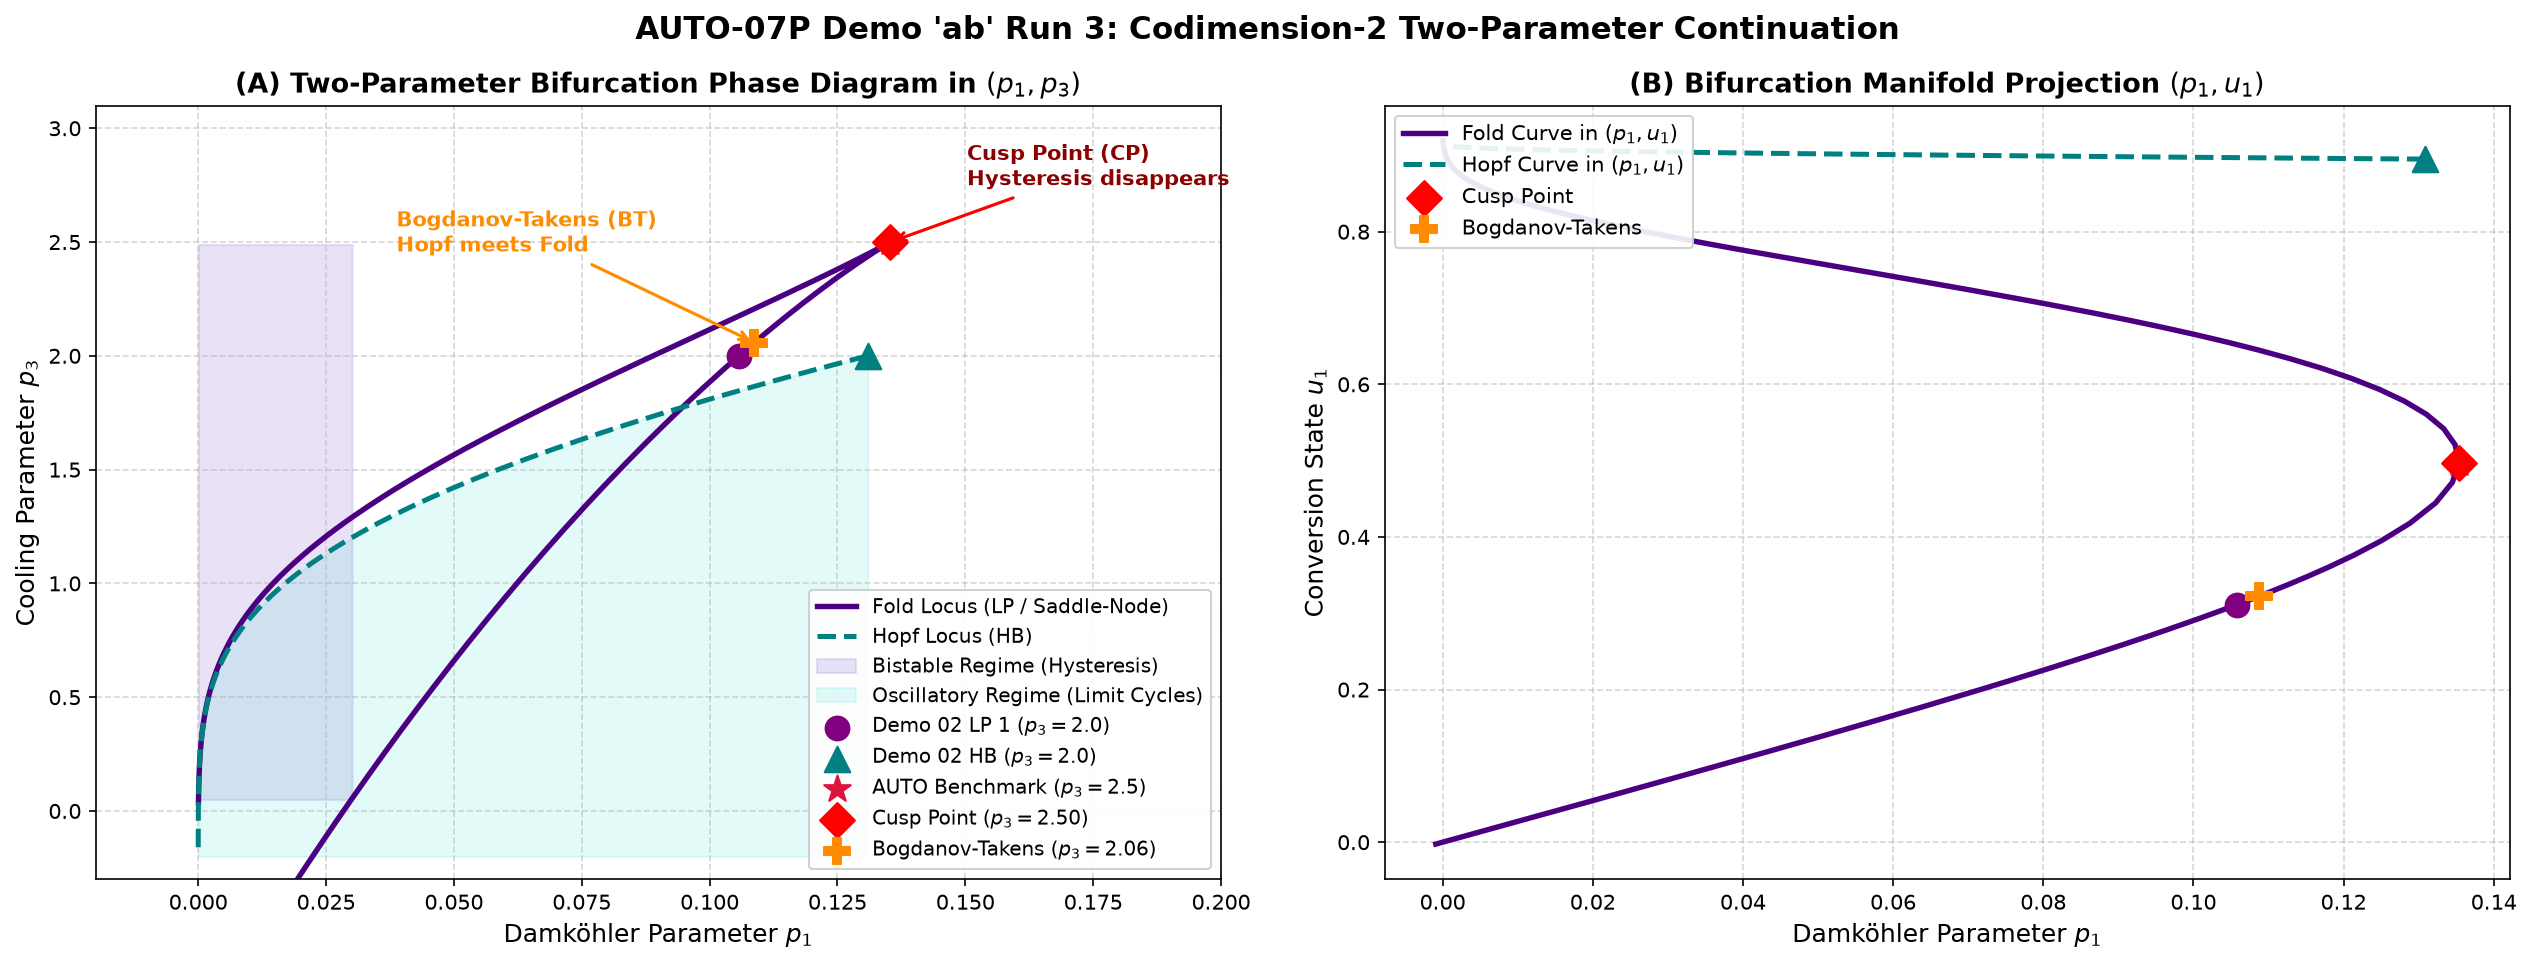

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6.5), dpi=150)

# Subplot 1: (p1, p3) Parameter Plane
ax1.plot(p1_fold, p3_fold, color="indigo", linewidth=2.6, label="Fold Locus (LP / Saddle-Node)")
ax1.plot(p1_hopf, p3_hopf, color="teal", linewidth=2.4, linestyle="--", label="Hopf Locus (HB)")

# Shading Bistable Cusp Wedge
# Interpolate fold curve for shading
p3_grid = np.linspace(0.05, p3_cusp - 0.01, 100)
p1_lower = np.interp(p3_grid, p3_fold[idx_cusp:], p1_fold[idx_cusp:])
p1_upper = np.interp(p3_grid, p3_fold[:idx_cusp], p1_fold[:idx_cusp])
ax1.fill_betweenx(
    p3_grid,
    p1_lower,
    p1_upper,
    color="mediumpurple",
    alpha=0.20,
    label="Bistable Regime (Hysteresis)",
)

# Shading Oscillatory Regime
ax1.fill_between(
    p1_hopf, p3_hopf, -0.2, color="turquoise", alpha=0.15, label="Oscillatory Regime (Limit Cycles)"
)

# Highlight Key Points
ax1.scatter(
    p1_lp1, p3_init, color="purple", s=130, zorder=6, marker="o", label="Demo 02 LP 1 ($p_3=2.0$)"
)
ax1.scatter(
    p1_hb, p3_init, color="teal", s=150, zorder=6, marker="^", label="Demo 02 HB ($p_3=2.0$)"
)
ax1.scatter(
    p1_num, p3_num, color="crimson", s=180, zorder=7, marker="*", label="AUTO Benchmark ($p_3=2.5$)"
)
ax1.scatter(
    p1_cusp,
    p3_cusp,
    color="red",
    s=140,
    zorder=7,
    marker="D",
    label=f"Cusp Point ($p_3={p3_cusp:.2f}$)",
)
ax1.scatter(
    p1_bt,
    p3_bt,
    color="darkorange",
    s=160,
    zorder=7,
    marker="P",
    label=f"Bogdanov-Takens ($p_3={p3_bt:.2f}$)",
)

# Annotations
ax1.annotate(
    "Cusp Point (CP)\nHysteresis disappears",
    xy=(p1_cusp, p3_cusp),
    xytext=(p1_cusp + 0.015, p3_cusp + 0.25),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=10,
    weight="bold",
    color="darkred",
)
ax1.annotate(
    "Bogdanov-Takens (BT)\nHopf meets Fold",
    xy=(p1_bt, p3_bt),
    xytext=(p1_bt - 0.07, p3_bt + 0.4),
    arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.5),
    fontsize=10,
    weight="bold",
    color="darkorange",
)

ax1.set_xlabel("Damköhler Parameter $p_1$", fontsize=12)
ax1.set_ylabel("Cooling Parameter $p_3$", fontsize=12)
ax1.set_title(
    "(A) Two-Parameter Bifurcation Phase Diagram in $(p_1, p_3)$", fontsize=13, weight="bold"
)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower right", framealpha=0.9, fontsize=9.5)
ax1.set_xlim(-0.02, 0.20)
ax1.set_ylim(-0.3, 3.1)

# Subplot 2: State-Parameter Projection (p1, u1)
ax2.plot(p1_fold, u1_fold, color="indigo", linewidth=2.6, label="Fold Curve in $(p_1, u_1)$")
ax2.plot(
    p1_hopf,
    u1_hopf,
    color="teal",
    linewidth=2.4,
    linestyle="--",
    label="Hopf Curve in $(p_1, u_1)$",
)
ax2.scatter(p1_lp1, u_lp1[0], color="purple", s=130, zorder=6, marker="o")
ax2.scatter(p1_hb, u_hb[0], color="teal", s=150, zorder=6, marker="^")
ax2.scatter(p1_num, u1_num, color="crimson", s=180, zorder=7, marker="*")
ax2.scatter(p1_cusp, u1_cusp, color="red", s=140, zorder=7, marker="D", label="Cusp Point")
ax2.scatter(
    p1_bt, u1_fold[idx_bt], color="darkorange", s=160, zorder=7, marker="P", label="Bogdanov-Takens"
)

ax2.set_xlabel("Damköhler Parameter $p_1$", fontsize=12)
ax2.set_ylabel("Conversion State $u_1$", fontsize=12)
ax2.set_title("(B) Bifurcation Manifold Projection $(p_1, u_1)$", fontsize=13, weight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left", framealpha=0.9, fontsize=10)

plt.suptitle(
    "AUTO-07P Demo 'ab' Run 3: Codimension-2 Two-Parameter Continuation", fontsize=15, weight="bold"
)
plt.tight_layout()
plt.show()

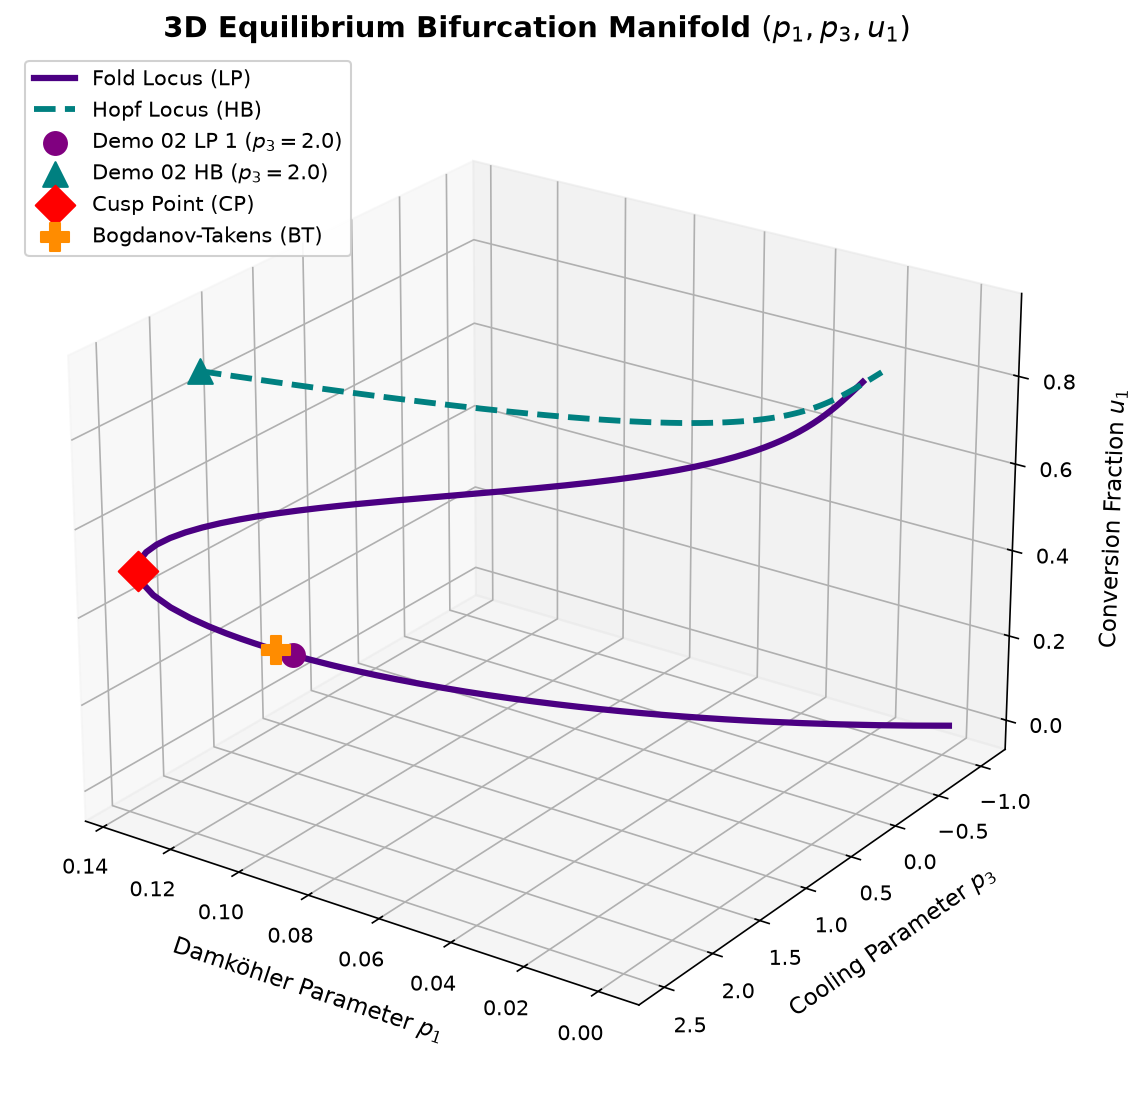

In [8]:
fig = plt.figure(figsize=(12, 7.5), dpi=150)
ax3d = fig.add_subplot(1, 1, 1, projection="3d")

# Plot 3D Fold and Hopf space curves
ax3d.plot(p1_fold, p3_fold, u1_fold, color="indigo", linewidth=3.0, label="Fold Locus (LP)")
ax3d.plot(
    p1_hopf, p3_hopf, u1_hopf, color="teal", linewidth=2.8, linestyle="--", label="Hopf Locus (HB)"
)

# Scatter critical points
ax3d.scatter(
    [p1_lp1],
    [p3_init],
    [u_lp1[0]],
    color="purple",
    s=120,
    marker="o",
    label="Demo 02 LP 1 ($p_3=2.0$)",
)
ax3d.scatter(
    [p1_hb], [p3_init], [u_hb[0]], color="teal", s=140, marker="^", label="Demo 02 HB ($p_3=2.0$)"
)
ax3d.scatter(
    [p1_cusp], [p3_cusp], [u1_cusp], color="red", s=180, marker="D", label="Cusp Point (CP)"
)
ax3d.scatter(
    [p1_bt],
    [p3_bt],
    [u1_fold[idx_bt]],
    color="darkorange",
    s=180,
    marker="P",
    label="Bogdanov-Takens (BT)",
)

ax3d.set_xlabel("Damköhler Parameter $p_1$", fontsize=11, labelpad=8)
ax3d.set_ylabel("Cooling Parameter $p_3$", fontsize=11, labelpad=8)
ax3d.set_zlabel("Conversion Fraction $u_1$", fontsize=11, labelpad=8)
ax3d.set_title("3D Equilibrium Bifurcation Manifold $(p_1, p_3, u_1)$", fontsize=14, weight="bold")
ax3d.view_init(elev=24, azim=125)
ax3d.legend(loc="upper left", framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()